# <b>Food Delivery Time Estimation project</b>

## Built on Linear regression concepts <i>((Closed-form solution)Normal Equation, Batch Gradient Descent, Ridge Regression)</i>

### Real-time datasets are messy hence need to perform Data-Engineering part too

In [1]:
import numpy as np
import pandas as pd
import pickle

In [2]:
class CustomLinearRegressionModel:
    def __init__(self, lr=0.1, epochs=1000, Lambda=1.0):
        self.lr = lr
        self.epochs = epochs
        # its supposed to be lambda, but py won't let me use as its reserved keyword.
        self.Lambda = Lambda
        # a single vector of slopes to all features [m1, m2, m3 ...]
        self.theta = None
        self.loss = []

    # Implementing Normal Equation
    def fit_normal_equation(self, X, y):
        # (X @ X.T)^-1 @ (X.T @ y)
        # self.theta = np.dot((np.linalg.inv(np.dot(X, X.T)), np.dot(X.T, y)))
        self.theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
        return self.theta

    # Implementing Ridge Regression
    def fit_ridge_regression(self, X, y):
        # (X @ X.T + Lambda @ I)-1 @ (X.T @ y)
        I = np.eye(X.shape[1])
        I[0,0] = 0
        # self.theta = np.linalg.inv(X.T.dot(X) + self.Lambda * I).dot(X.T).dot(y)
        # self.theta = np.dot(np.linalg.inv(np.dot(X.T, X) + self.Lambda * I), np.dot(X.T, y))
        self.theta = np.linalg.inv(X.T @ X + self.Lambda * I) @ X.T @ y
        return self.theta

    # Implementing Batch Gradient descent (BGD)
    def fit_batch_gradient_descent(self, X, y):
        # y = m*x
        self.theta = np.zeros(X.shape[1])
        m = len(y)
        for _ in range(self.epochs+1):
            pred = X @ self.theta
            err = pred - y

            # update gradients to weights
            # 1/m if lr = 0.1, 2/m if lr = 0.05
            self.theta -= self.lr * (2/m) * X.T @ err

            # append loss
            loss = (err ** 2).mean()
            self.loss.append(loss)

        return self.theta


## One-hot encoding categorical cols, new project build as follows

In [3]:
df = pd.read_csv('./deliverytime.csv')
df

df.drop(["ID", "Delivery_person_ID"], axis=1, inplace=True)

In [4]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


### Logic to convert locations of restraunts and delivery locations to actual distances as per earth's curvature.

In [5]:
def haversine(lat1, lon1, lat2, lon2):
        R = 6371 # Earth radius in km
        dLat, dLon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
        a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2
        return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

df['distance_km'] = haversine(df['Restaurant_latitude'], df['Restaurant_longitude'], 
                                  df['Delivery_location_latitude'], df['Delivery_location_longitude'])

df = df[(df['Time_taken(min)'] > 0) & (df['Time_taken(min)'] < 120)]
df = df[(df['distance_km'] < 100)]
df['Type_of_order'] = df['Type_of_order'].str.strip()
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()
# binning method
df['distance_bucket'] = pd.qcut(df['distance_km'], q=4, labels=[1, 2, 3, 4]).astype(int)

### Also dealing with missing data

In [6]:
df = df.fillna(df.median(numeric_only=True))
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),distance_km,distance_bucket
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.025149,1
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.183530,4
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.552758,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.790401,2
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.210138,2
...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,1.489846,1
45589,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,36,11.007735,3
45590,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,4.657195,1
45591,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,6.232393,2


### one-hot encoding categorical columns with 0, 1's. Hence dtype='unint8'

In [7]:
# if dtype='uint8' not provided, encoded cols will have Boolean values instead of 0's and 1's.
new_df = pd.get_dummies(df, columns=['Type_of_order', 'Type_of_vehicle'], drop_first=True, dtype='uint8')
new_df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min),distance_km,distance_bucket,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,22.745049,75.892471,22.765049,75.912471,24,3.025149,1,0,0,1,0,1,0
1,34,4.5,12.913041,77.683237,13.043041,77.813237,33,20.183530,4,0,0,1,0,0,1
2,23,4.4,12.914264,77.678400,12.924264,77.688400,26,1.552758,1,1,0,0,0,1,0
3,38,4.7,11.003669,76.976494,11.053669,77.026494,21,7.790401,2,0,0,0,0,1,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,30,6.210138,2,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,26.902328,75.794257,26.912328,75.804257,32,1.489846,1,0,1,0,0,1,0
45589,21,4.6,0.000000,0.000000,0.070000,0.070000,36,11.007735,3,0,0,0,0,1,0
45590,30,4.9,13.022394,80.242439,13.052394,80.272439,16,4.657195,1,1,0,0,0,0,1
45591,20,4.7,11.001753,76.986241,11.041753,77.026241,26,6.232393,2,0,0,1,0,1,0


### Dropping unecessary columns

In [8]:
new_df.drop(columns=["Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude", "Delivery_location_longitude"], inplace=True)

In [9]:
new_df

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),distance_km,distance_bucket,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,24,3.025149,1,0,0,1,0,1,0
1,34,4.5,33,20.183530,4,0,0,1,0,0,1
2,23,4.4,26,1.552758,1,1,0,0,0,1,0
3,38,4.7,21,7.790401,2,0,0,0,0,1,0
4,32,4.6,30,6.210138,2,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,32,1.489846,1,0,1,0,0,1,0
45589,21,4.6,36,11.007735,3,0,0,0,0,1,0
45590,30,4.9,16,4.657195,1,1,0,0,0,0,1
45591,20,4.7,26,6.232393,2,0,0,1,0,1,0


#### Extracting one-hot-encoded column names

In [10]:
dummy_cols = [col for col in new_df.columns if 'Type_of_order_' in col or 'Type_of_vehicle_' in col]
dummy_cols

['Type_of_order_Drinks',
 'Type_of_order_Meal',
 'Type_of_order_Snack',
 'Type_of_vehicle_electric_scooter',
 'Type_of_vehicle_motorcycle',
 'Type_of_vehicle_scooter']

#### Extracting other continuous and defining interaction columns

In [11]:
continuous_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'distance_bucket']
target_col = ['Time_taken(min)']
interaction_cols = ['interaction_distance_x_electric_scooter', 'interaction_distance_x_motorcycle', 'interaction_distance_x_scooter']

### Adding interaction columns to dataset.
#### Bicycle can be faster for shorter distances but motorcycle is faster for longer distance

In [12]:
distance_mean = new_df['distance_km'].values.mean(axis=0)
distance_std = new_df['distance_km'].values.std(axis=0)

scaled_distance = (new_df['distance_km'] - distance_mean) / distance_std

new_df[interaction_cols[0]] = scaled_distance * new_df['Type_of_vehicle_electric_scooter']
new_df[interaction_cols[1]] = scaled_distance * new_df['Type_of_vehicle_motorcycle']
new_df[interaction_cols[2]] = scaled_distance * new_df['Type_of_vehicle_scooter']

#### Creating final DataFrame to finally use

In [13]:
feature_cols = continuous_cols + dummy_cols + interaction_cols
new_df[feature_cols]

,Delivery_person_Age,Delivery_person_Ratings,distance_km,distance_bucket,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,interaction_distance_x_electric_scooter,interaction_distance_x_motorcycle,interaction_distance_x_scooter
0,37,4.9,3.025149,1,0,0,1,0,1,0,-0.0,-1.196454,-0.000000
1,34,4.5,20.183530,4,0,0,1,0,0,1,0.0,0.000000,1.862929
2,23,4.4,1.552758,1,1,0,0,0,1,0,-0.0,-1.458985,-0.000000
3,38,4.7,7.790401,2,0,0,0,0,1,0,-0.0,-0.346798,-0.000000
4,32,4.6,6.210138,2,0,0,1,0,0,1,-0.0,-0.000000,-0.628562
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30,4.8,1.489846,1,0,1,0,0,1,0,-0.0,-1.470202,-0.000000
45589,21,4.6,11.007735,3,0,0,0,0,1,0,0.0,0.226861,0.000000
45590,30,4.9,4.657195,1,1,0,0,0,0,1,-0.0,-0.000000,-0.905456
45591,20,4.7,6.232393,2,0,0,1,0,1,0,-0.0,-0.624594,-0.000000


In [14]:
X_raw = new_df[feature_cols].values
y = new_df[target_col].values
X_raw, y

(array([[37.        ,  4.9       ,  3.02514929, ..., -0.        ,
         -1.19645398, -0.        ],
        [34.        ,  4.5       , 20.18352973, ...,  0.        ,
          0.        ,  1.8629286 ],
        [23.        ,  4.4       ,  1.5527578 , ..., -0.        ,
         -1.45898511, -0.        ],
        ...,
        [30.        ,  4.9       ,  4.65719539, ..., -0.        ,
         -0.        , -0.90545604],
        [20.        ,  4.7       ,  6.23239305, ..., -0.        ,
         -0.62459432, -0.        ],
        [23.        ,  4.9       , 12.07439553, ...,  0.        ,
          0.        ,  0.41704948]], shape=(45162, 13)),
 array([[24],
        [33],
        [26],
        ...,
        [16],
        [26],
        [36]], shape=(45162, 1)))

### Standardizing all continous cols (leaving encoded/interaction cols) as is

In [15]:
X_continuous = X_raw[:, :len(continuous_cols)]
X_encoded = X_raw[:, len(continuous_cols):-len(interaction_cols)]
X_interaction_cols = X_raw[:, -len(interaction_cols):]

X_continuous, X_encoded, X_interaction_cols

(array([[37.        ,  4.9       ,  3.02514929,  1.        ],
        [34.        ,  4.5       , 20.18352973,  4.        ],
        [23.        ,  4.4       ,  1.5527578 ,  1.        ],
        ...,
        [30.        ,  4.9       ,  4.65719539,  1.        ],
        [20.        ,  4.7       ,  6.23239305,  2.        ],
        [23.        ,  4.9       , 12.07439553,  3.        ]],
       shape=(45162, 4)),
 array([[0., 0., 1., 0., 1., 0.],
        [0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 0., 1., 0.],
        ...,
        [1., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 1., 0.],
        [0., 0., 1., 0., 0., 1.]], shape=(45162, 6)),
 array([[-0.        , -1.19645398, -0.        ],
        [ 0.        ,  0.        ,  1.8629286 ],
        [-0.        , -1.45898511, -0.        ],
        ...,
        [-0.        , -0.        , -0.90545604],
        [-0.        , -0.62459432, -0.        ],
        [ 0.        ,  0.        ,  0.41704948]], shape=(45162, 3)))

In [16]:
X_mean = X_continuous.mean(axis=0)
X_std = X_continuous.std(axis=0)

X_scaled = (X_continuous - X_mean) / X_std
X_scaled

array([[ 1.31046128,  0.82784076, -1.19645398, -1.34093999],
       [ 0.78346531, -0.4109374 ,  1.8629286 ,  1.34177162],
       [-1.14885323, -0.72063194, -1.45898511, -1.34093999],
       ...,
       [ 0.08080403,  0.82784076, -0.90545604, -1.34093999],
       [-1.67584919,  0.20845168, -0.62459432, -0.44670279],
       [-1.14885323,  0.82784076,  0.41704948,  0.44753441]],
      shape=(45162, 4))

#### Adding a Bias column as final step

In [17]:
X_final = np.c_[np.ones(X_scaled.shape[0]), X_scaled]
X = np.hstack((X_final, X_encoded, X_interaction_cols))
X

array([[ 1.        ,  1.31046128,  0.82784076, ..., -0.        ,
        -1.19645398, -0.        ],
       [ 1.        ,  0.78346531, -0.4109374 , ...,  0.        ,
         0.        ,  1.8629286 ],
       [ 1.        , -1.14885323, -0.72063194, ..., -0.        ,
        -1.45898511, -0.        ],
       ...,
       [ 1.        ,  0.08080403,  0.82784076, ..., -0.        ,
        -0.        , -0.90545604],
       [ 1.        , -1.67584919,  0.20845168, ..., -0.        ,
        -0.62459432, -0.        ],
       [ 1.        , -1.14885323,  0.82784076, ...,  0.        ,
         0.        ,  0.41704948]], shape=(45162, 14))

## Calling the models

In [18]:
custom_model = CustomLinearRegressionModel(lr=0.1, epochs=5000, Lambda=1.0)

y = y.flatten()

# Normal Equation
neq_theta = custom_model.fit_normal_equation(X, y)

# Ridge Regression
rr_theta = custom_model.fit_ridge_regression(X, y)

# Batch Gradient Descent
bgd_theta = custom_model.fit_batch_gradient_descent(X, y)

print('\nOutput of all 3 models\n')
print("\nNormal Equation         :", neq_theta)
print("\nRidge Regression        :", rr_theta)
print("\nBatch Gradient Descent  :", bgd_theta)


Output of all 3 models


Normal Equation         : [23.92160041  2.55640727 -2.65005492  2.95802405  2.42903437 -0.0838721
  0.11940936  0.02454518  0.54379631  3.63009415  0.62506715 -2.86720911
 -2.24175777 -2.89266324]

Ridge Regression        : [23.96954777  2.55634205 -2.6498872   2.74830955  2.42913864 -0.08366145
  0.11956094  0.02475284  0.49556645  3.58187142  0.57693114 -2.656851
 -2.03206156 -2.68283636]

Batch Gradient Descent  : [20.18820616  2.55499074 -2.65534884  0.60909357  2.43551138 -0.07905143
  0.12752219  0.02871652  4.28406563  7.3606786   4.35704989 -0.5209919
  0.10151954 -0.54990545]


## Predicting a sample

In [19]:
# 1. Define raw inputs
age = 30
rating = 4.5
distance = 8.0
bucket = 3

# 2. Scale continuous inputs
scaled_age = (age - X_mean[0]) / X_std[0]
scaled_rating = (rating - X_mean[1]) / X_std[1]
scaled_dist = (distance - X_mean[2]) / X_std[2]
scaled_bucket = (bucket - X_mean[3]) / X_std[3]

# 3. Define Dummies 
# Order = [Drinks, Meal, Snack] -> Meal is 1
type_of_order = [0.0, 1.0, 0.0]
# Vehicle = [Electric, Moto, Scooter] -> Moto is 1
type_of_vehicle = [0.0, 1.0, 0.0]

# 4. CALCULATE INTERACTION TERMS FOR THE SAMPLE
inter_elec = scaled_dist * type_of_vehicle[0]
inter_moto = scaled_dist * type_of_vehicle[1]
inter_scoot = scaled_dist * type_of_vehicle[2]
interactions = [inter_elec, inter_moto, inter_scoot]

# 5. Build the final array (Notice we add EVERYTHING)
sample = np.hstack(([1.0], [scaled_age, scaled_rating, scaled_dist, scaled_bucket], type_of_order, type_of_vehicle, interactions))

# 6. Predict
rr = (rr_theta @ sample).sum()
print("Ridge Regression Prediction:", rr.round(2), "minutes")

Ridge Regression Prediction: 29.83 minutes


## Extracting artifacts (theta). Preferred method: Ridge Regression
#### Because it handles multicollinearity.

In [20]:
artifacts = {
    "theta": rr_theta,
    "X_mean": X_mean,
    "X_std": X_std,
    "feature_cols": feature_cols
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Pickle file generated successfully")

Pickle file generated successfully


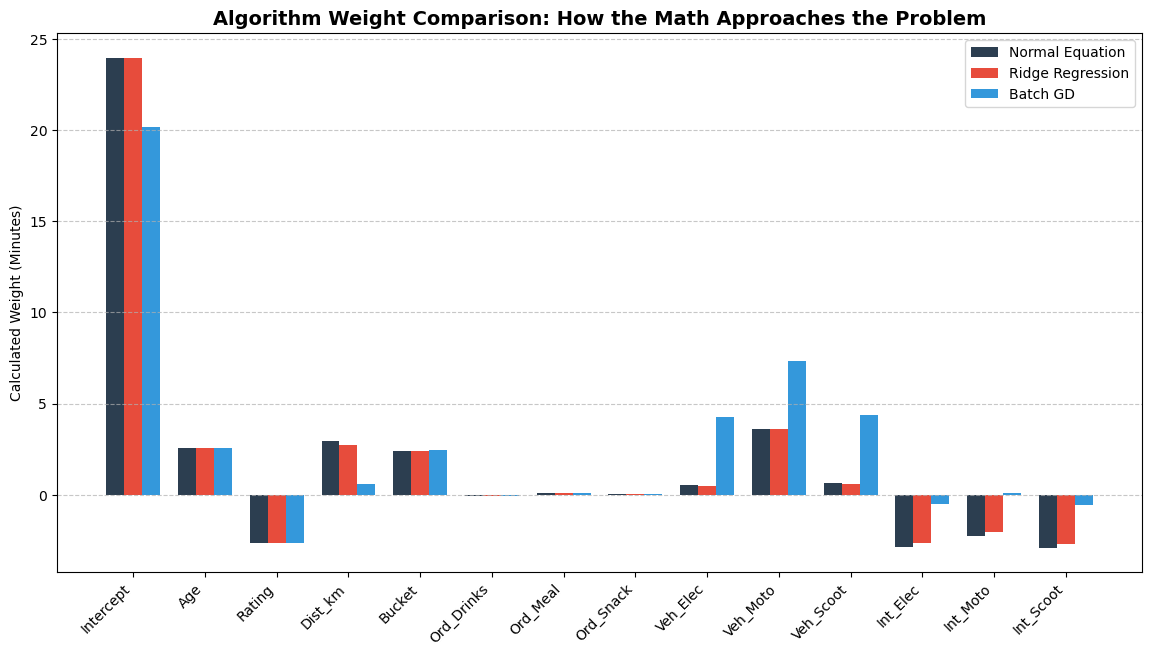

Plots saved successfully!


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Setup ---
# Feature names for the X-axis
features = ['Intercept', 'Age', 'Rating', 'Dist_km', 'Bucket', 
            'Ord_Drinks', 'Ord_Meal', 'Ord_Snack', 
            'Veh_Elec', 'Veh_Moto', 'Veh_Scoot', 
            'Int_Elec', 'Int_Moto', 'Int_Scoot']

# Assuming your notebook still has these arrays loaded from your final cell
# If not, you can paste the exact printed arrays here.
theta_neq = neq_theta 
theta_rr = rr_theta
theta_bgd = bgd_theta

# ==========================================
# PLOT 1: Algorithm Coefficient Comparison
# ==========================================
x = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width, theta_neq, width, label='Normal Equation', color='#2c3e50')
rects2 = ax.bar(x, theta_rr, width, label='Ridge Regression', color='#e74c3c')
rects3 = ax.bar(x + width, theta_bgd, width, label='Batch GD', color='#3498db')

ax.set_ylabel('Calculated Weight (Minutes)')
ax.set_title('Algorithm Weight Comparison: How the Math Approaches the Problem', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


# plt.tight_layout()
# plt.savefig('model_weights_comparison.png', dpi=300)
# plt.close()

print("Plots saved successfully!")

In [29]:

# ==========================================
# PLOT 2: The Interaction Crossover (Bike vs Moto)
# ==========================================
# Let's visualize the Ridge Regression predicting deliveries from 1km to 25km
distances_to_plot = np.linspace(1, 25, 100)

# We hold other variables constant (Average Age, Average Rating)
# Since they are standardized, "average" is just 0.0
bike_times = []
moto_times = []

for dist in distances_to_plot:
    # Scale the distance using the standard deviation from your dataset
    scaled_dist = (dist - X_mean[2]) / X_std[2]
    
    # Bicycle Array (All vehicle & interaction dummies are 0)
    bike_sample = np.array([1.0, 0, 0, scaled_dist, 0,  0, 0, 0,  0, 0, 0,  0, 0, 0])
    bike_times.append(theta_rr @ bike_sample)
    
    # Motorcycle Array (Moto dummy is 1, Moto interaction is calculated)
    moto_interaction = scaled_dist * 1.0
    moto_sample = np.array([1.0, 0, 0, scaled_dist, 0,  0, 0, 0,  0, 1.0, 0,  0, moto_interaction, 0])
    moto_times.append(theta_rr @ moto_sample)

plt.figure(figsize=(10, 6))
plt.plot(distances_to_plot, bike_times, label='Bicycle', color='#2ecc71', linewidth=3)
plt.plot(distances_to_plot, moto_times, label='Motorcycle', color='#e74c3c', linewidth=3)

# Mark the crossover point
plt.axvline(x=19.6, color='gray', linestyle='--', alpha=0.7)
plt.text(19.8, 25, 'Crossover (~19.6km)', rotation=90, color='gray')

plt.title('Impact of Interaction Terms: Bicycle vs. Motorcycle Speed', fontsize=14, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Predicted Time (minutes)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# plt.show()

plt.tight_layout()
plt.savefig('interaction_crossover.png', dpi=300)
plt.close()

In [30]:
plt.show()

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate predictions and residuals
y_pred = X @ artifacts['theta']
residuals = y - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='#5485ff')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # The "Perfect Prediction" line
plt.title('Residuals vs Predicted Time: Finding the Errors', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Delivery Time (minutes)')
plt.ylabel('Residual Error (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.close()

In [32]:
plt.show()